In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# load data
housing = fetch_california_housing()

print(housing.DESCR)

# look at the data frame
print("feature matrix shape:", housing.data.shape)
print("target vector shape:", housing.target.shape)

print(housing.feature_names)
print(housing.data[0])
print(housing.target[0])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
from sklearn import tree

X = housing.data[:, [6, 7]]
y = housing.target

#  create decision tree, the maximum depth is 2
dtr = tree.DecisionTreeRegressor(max_depth=2)

dtr.fit(X, y)

print("Model fit on training set")
print(dtr)

Model fit on training set
DecisionTreeRegressor(max_depth=2)


In [4]:
pip install graphviz pydotplus

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24635 sha256=f421554f1faa34384b4ef7591a8a56ce250edb71748f1449c8afe5a341edfa3a
  Stored in directory: /Users/apple/Library/Caches/pip/wheels/4a/c0/ed/a9eeeb08c3c53bb90d3822cf76557c8fdcbc349ee11a011169
Successfully built pydotplus
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [graphviz]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
conda install graphviz python-graphviz

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /Users/apple/anaconda3

  added / updated specs:
    - graphviz
    - python-graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.16  |       hca03da5_0         106 KB
    cairo-1.16.0               |       hd886ae0_6         1.0 MB
    certifi-2026.6.17          |  py313hca03da5_0         131 KB
    font-ttf-dejavu-sans-mono-2.37|       hd3eb1b0_0         335 KB
    font-ttf-inconsolata-2.001 |       hcb22688_0          83 KB
    font-ttf-source-code-pro-2.030|       hd3eb1b0_0         654 KB
    font-ttf-ubuntu-0.83       |       h8b1ccd4_0         1.5 MB
    fontconfig-2.15.0          |       h29935d0_0         225 KB
    fonts-anaconda-1           |       h8fa9717_0           3 KB
   

In [8]:
dot_data = tree.export_graphviz(
    dtr,
    out_file=None,
    feature_names=housing.feature_names[6:8],
    filled=True,
    impurity=False,
    rounded=True
)

import pydotplus
graph = pydotplus.graph_from_dot_data(dot_data)

graph.get_nodes()[7].set_fillcolor('#FFF2DD')

from IPython.display import Image
Image(graph.create_png())
graph.write_png('tree.png')

True

In [9]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    housing.data, housing.target, test_size=0.1, random_state=42
)

print("Training set size:", data_train.shape)
print("Test set size:", data_test.shape)

dtr = tree.DecisionTreeRegressor(random_state=42)
dtr.fit(data_train, target_train)

score = dtr.score(data_test, target_test)
print("R-squared score on test set:", score)


Training set size: (18576, 8)
Test set size: (2064, 8)
R-squared score on test set: 0.633983914133596


In [12]:
for depth in [2, 5, 10, 20, None]:
    m = tree.DecisionTreeRegressor(max_depth=depth, random_state=42)
    m.fit(data_train, target_train)
    print(f"Depth: {depth}, Accuracy: {m.score(data_test, target_test)}")

Depth: 2, Accuracy: 0.4277666480994945
Depth: 5, Accuracy: 0.5914099985412158
Depth: 10, Accuracy: 0.687526820191182
Depth: 20, Accuracy: 0.6473659121453268
Depth: None, Accuracy: 0.633983914133596


In [13]:
# Random Forests
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(data_train, target_train)

# score
print("train score:", rf.score(data_train, target_train))
print("test score:", rf.score(data_test, target_test))

# compare with decision tree
print("decision tree score:", dtr.score(data_test, target_test))

train score: 0.9738463266505786
test score: 0.8100235002294932
decision tree score: 0.633983914133596


In [15]:
from sklearn.model_selection import GridSearchCV

# 1. define the paramter grid
tree_parameter_grid = {
    'min_samples_split':[3, 6, 9],
    'n_estimators': [10, 50, 100]
}

# 2. define the grid search object
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=tree_parameter_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 3. begin the grid search
grid.fit(data_train, target_train)

# 4. get the best parameters
print("Best parameters found: ", grid.best_params_)
print("Best cross-validation score: ", grid.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters found:  {'min_samples_split': 3, 'n_estimators': 100}
Best cross-validation score:  0.8071917580771188


In [ ]:
best_model = grid.best_estimator_
print("best model score:", best_model.score(data_test, target_test))

best model score: 0.8092138832000872


Exception ignored in: <function ResourceTracker.__del__ at 0x106767100>
Traceback (most recent call last):
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10670f100>
Traceback (most recent call last):
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/apple/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

final score: 0.8092138832000872
best estimator score: 0.8092138832000872
MedInc        0.524238
AveOccup      0.137960
Latitude      0.090666
Longitude     0.089249
HouseAge      0.053950
AveRooms      0.044532
Population    0.030273
AveBedrms     0.029133
dtype: float64


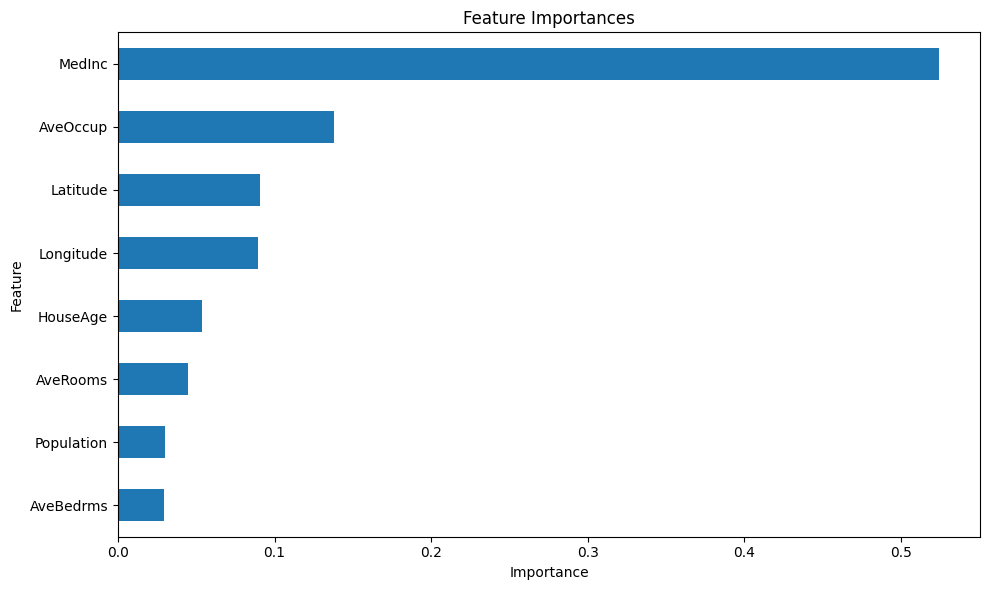

In [19]:
# 1. retrain the model with best parameters
rfr_best = RandomForestRegressor(
    min_samples_split=3,
    n_estimators=100,
    random_state=42
)

rfr_best.fit(data_train, target_train)

print("final score:", rfr_best.score(data_test, target_test))
# 2. compare with the model which GridSearchCV found
print("best estimator score:", grid.best_estimator_.score(data_test, target_test))

# 3. got the feature importance
importances = pd.Series(
    rfr_best.feature_importances_,
    index=housing.feature_names
).sort_values(ascending=False)

print(importances.head(10))
from matplotlib import pyplot as plt
# 4. plot the feature importance
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

